1. Install + Imports
2. Data + Feature Engineering
3. Strategy Functions (human knowledge)
4. Web Scraping
5. LLM Interpretation
6. Signal Generation
7. Environment
8. RL Model
9. Evaluation
10. Knowledge Base
11. Critique + Improvement
12. MAIN LOOP (self-improving agent)
13. Final Model Save

In [2]:
!pip install yfinance gymnasium stable-baselines3 groq BeautifulSoup4 requests
!pip install stable-baselines3[extra]
!pip install torch matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 11.2 MB/s eta 0:00:00


In [32]:
import yfinance as yf
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import gymnasium as gym
from bs4 import BeautifulSoup
import requests
from stable_baselines3 import PPO

In [4]:
from groq import Groq

client = Groq(api_key="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")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.clip(lower=0)).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / (loss + 1e-8)
    return 100 - (100 / (1 + rs))

In [24]:
def load_data(csv_path=None):
    if csv_path:
        df = pd.read_csv(csv_path)
    else:
        import yfinance as yf
        df = yf.download("AAPL", start="2015-01-01", end="2023-01-01")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[['Close', 'Volume']].copy()

    # ===== FEATURES =====
    df['returns'] = np.log(df['Close'] / df['Close'].shift(1))
    df['ma_10'] = df['Close'].rolling(10).mean()
    df['ma_20'] = df['Close'].rolling(20).mean()
    df['volatility'] = df['returns'].rolling(10).std()
    df['momentum'] = df['Close'] / df['Close'].shift(10) - 1

    # RSI
    delta = df['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    df['rsi'] = 100 - (100 / (1 + rs))

    # ===== LABEL (CRITICAL) =====
    horizon = 5
    df['future_return'] = df['Close'].shift(-horizon) / df['Close'] - 1

    df['signal'] = 0
    df.loc[df['future_return'] > 0.01, 'signal'] = 1
    df.loc[df['future_return'] < -0.01, 'signal'] = -1

    df = df.dropna().copy()

    return df

In [25]:
def get_signal(df):
    return df['signal'].values

In [7]:
def trend_strategy(df):
    return (df['Close'] > df['ma']).astype(int)

def mean_reversion_strategy(df):
    return (df['rsi'] < 30).astype(int)

def breakout_strategy(df):
    return (df['volatility'] > df['volatility'].rolling(20).mean()).astype(int)

In [11]:
knowledge_base = []

def store(strategy, sharpe):
    knowledge_base.append({
        "strategy": strategy,
        "sharpe": sharpe
    })

def get_best():
    return max(knowledge_base, key=lambda x: x["sharpe"])

In [12]:
top_k = sorted(knowledge_base, key=lambda x: x["sharpe"], reverse=True)[:3]

kb_signals = []

for item in top_k:
    try:
        sig = parse_strategy(item["strategy"], df)
        kb_signals.append(sig)
    except:
        continue

In [13]:
def generate_multi_signals(df):

    signals = []

    # Strategy 1: Mean Reversion
    signals.append((df['rsi'] < 30).astype(int))

    # Strategy 2: Trend Following
    signals.append((df['Close'] > df['ma']).astype(int))

    # Strategy 3: Momentum
    signals.append((df['momentum'] > 0).astype(int))

    return signals

In [26]:
class TradingEnv(gym.Env):
    def __init__(self, df):
        super().__init__()

        self.df = df.reset_index(drop=True)
        self.n_steps = len(df)

        # 0 HOLD, 1 BUY, 2 SELL
        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32
        )

        self.initial_cash = 10000

    def reset(self, seed=None, options=None):
        self.step_idx = 0
        self.cash = self.initial_cash
        self.shares = 0

        self.history = []

        return self._get_obs(), {}

    def _get_obs(self):
        row = self.df.iloc[self.step_idx]
        return np.array([
            row['returns'],
            row['ma_10'],
            row['ma_20'],
            row['volatility'],
            row['momentum'],
            row['rsi']
        ], dtype=np.float32)

    def step(self, action):

        price = self.df.iloc[self.step_idx]['Close']
        prev_value = self.cash + self.shares * price

        # ===== ACTIONS =====
        if action == 1:  # BUY
            if self.cash > 0:
                self.shares = self.cash / price
                self.cash = 0

        elif action == 2:  # SELL
            if self.shares > 0:
                self.cash = self.shares * price
                self.shares = 0

        # HOLD = do nothing

        self.step_idx += 1
        done = self.step_idx >= self.n_steps - 1

        next_price = self.df.iloc[self.step_idx]['Close']
        value = self.cash + self.shares * next_price

        reward = np.log((value + 1e-8) / (prev_value + 1e-8))

        # ===== LOG EVERYTHING =====
        self.history.append({
            "step": self.step_idx,
            "price": next_price,
            "action": action,
            "cash": self.cash,
            "shares": self.shares,
            "value": value
        })

        return self._get_obs(), reward, done, False, {}

In [27]:
def evaluate(model, env):
    obs, _ = env.reset()

    for _ in range(env.n_steps - 1):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(int(action))
        if done:
            break

    history = pd.DataFrame(env.history)

    return history

In [28]:
def plot_results(df, history):

    # ===== PRICE + TRADES =====
    plt.figure()
    plt.plot(df['Close'].values, label="Price")

    buys = history[history['action'] == 1]
    sells = history[history['action'] == 2]

    plt.scatter(buys['step'], buys['price'], marker='^')
    plt.scatter(sells['step'], sells['price'], marker='v')

    plt.title("Price + Trades")
    plt.legend()
    plt.show()

    # ===== EQUITY CURVE =====
    plt.figure()
    plt.plot(history['value'])
    plt.title("Equity Curve")
    plt.show()

    # ===== ACTION DISTRIBUTION =====
    plt.figure()
    history['action'].value_counts().plot(kind='bar')
    plt.title("Action Distribution")
    plt.show()

In [30]:
def compute_metrics(history):
    values = history['value'].values
    returns = np.diff(np.log(values + 1e-8))

    sharpe = returns.mean() / (returns.std() + 1e-8)
    drawdown = np.min(values) / np.max(values) - 1

    metrics = pd.DataFrame({
        "Metric": ["Sharpe", "Drawdown"],
        "Value": [sharpe, drawdown]
    })

    print(metrics)

In [17]:
def critique(entry):
    feedback = []

    if entry["sharpe"] < 0.1:
        feedback.append("weak")

    if entry["drawdown"] < -0.3:
        feedback.append("risky")

    return feedback

In [18]:
def improve(model, feedback):

    if "weak" in feedback:
        model.ent_coef = min(model.ent_coef + 0.01, 0.05)

    if "risky" in feedback:
        model.learn(total_timesteps=5000, reset_num_timesteps=False)

In [33]:
def train_ppo(env):
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        gamma=0.99,
        verbose=1
    )

    model.learn(total_timesteps=20000)

    return model

In [34]:
def train_test_split(df, split=0.7):
    split_idx = int(len(df) * split)

    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    return train_df, test_df

In [35]:
import matplotlib.pyplot as plt

def analyze(values):

    values = np.array(values)

    returns = np.diff(np.log(values + 1e-8))

    sharpe = np.mean(returns) / (np.std(returns) + 1e-8)

    drawdown = np.min(values) / np.max(values) - 1

    print("Sharpe:", sharpe)
    print("Drawdown:", drawdown)

    plt.plot(values)
    plt.title("Equity Curve")
    plt.show()

In [36]:
def walk_forward_validation(df, window=500, step=100):

    all_results = []

    for start in range(0, len(df) - window - step, step):

        train_df = df.iloc[start:start+window]
        test_df = df.iloc[start+window:start+window+step]

        # TRAIN
        train_env = TradingEnv(train_df)
        model = train_ppo(train_env)

        # TEST
        test_env = TradingEnv(test_df)
        history = evaluate(model, test_env)

        history['window_start'] = start

        all_results.append(history)

    final_history = pd.concat(all_results, ignore_index=True)

    return final_history

/tmp/ipykernel_3131/807836562.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2015-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.39e+03 |
|    ep_rew_mean     | 0.578    |
| time/              |          |
|    fps             | 932      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.39e+03    |
|    ep_rew_mean          | 0.271       |
| time/                   |             |
|    fps                  | 746         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008658124 |
|    clip_fraction        | 0.0362      |
|    clip_range           | 0.2         |
|    entropy_loss   

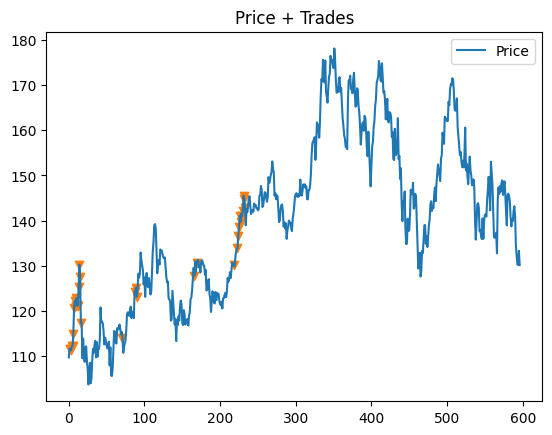

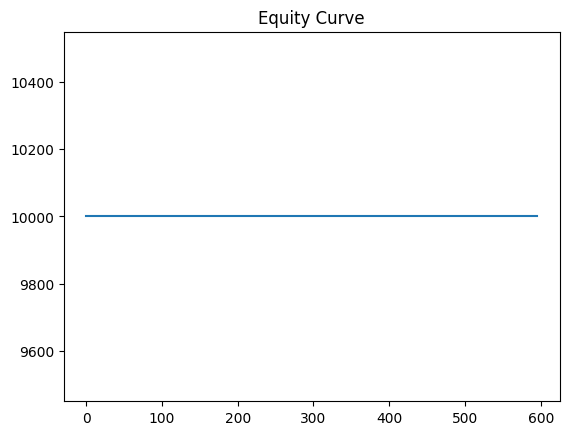

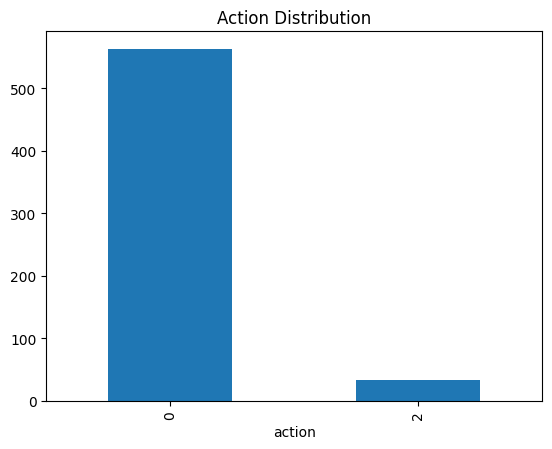

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


     Metric  Value
0    Sharpe    0.0
1  Drawdown    0.0
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 499      |
|    ep_rew_mean     | -0.0315  |
| time/              |          |
|    fps             | 950      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 499         |
|    ep_rew_mean          | -0.0186     |
| time/                   |             |
|    fps                  | 645         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.012273404 |
|    clip_fraction        | 0.133       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.703      |
|    learning_rate        | 0.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 499      |
|    ep_rew_mean     | 0.537    |
| time/              |          |
|    fps             | 959      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 499         |
|    ep_rew_mean          | 0.524       |
| time/                   |             |
|    fps                  | 762         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.014116394 |
|    clip_fraction        | 0.0755      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.0486     |
|    learning_rate        | 0.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 499      |
|    ep_rew_mean     | 0.391    |
| time/              |          |
|    fps             | 814      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 499          |
|    ep_rew_mean          | 0.352        |
| time/                   |              |
|    fps                  | 705          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0077763544 |
|    clip_fraction        | 0.0575       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.09        |
|    explained_variance   | -1.48        |
|    learning_r

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 499      |
|    ep_rew_mean     | 0.564    |
| time/              |          |
|    fps             | 948      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 499         |
|    ep_rew_mean          | 0.541       |
| time/                   |             |
|    fps                  | 672         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010226615 |
|    clip_fraction        | 0.0614      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.481      |
|    learning_rate        | 0.

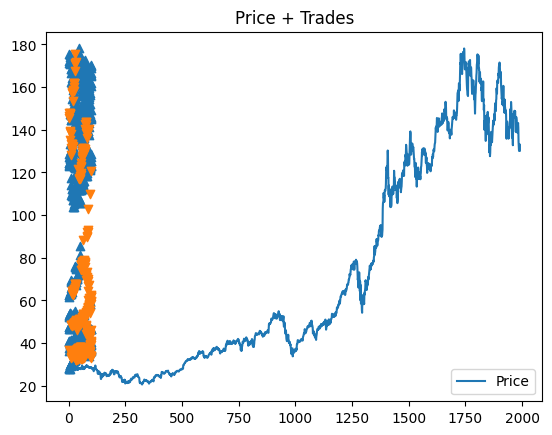

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


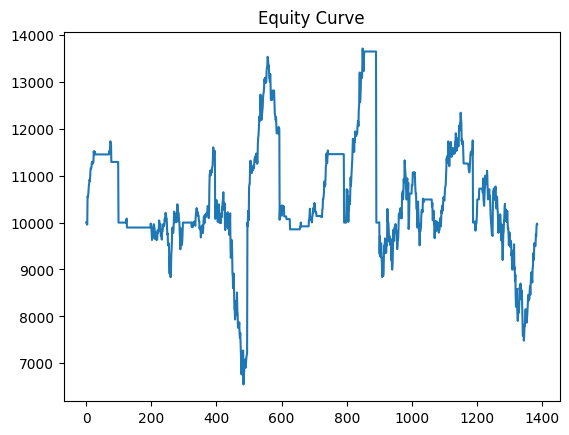

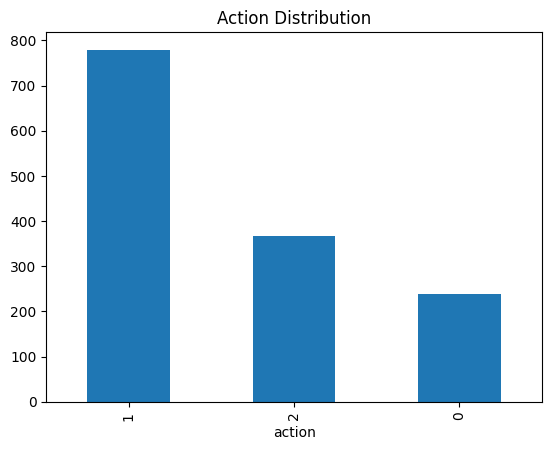

     Metric     Value
0    Sharpe -0.000123
1  Drawdown -0.522603


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [37]:
df = load_data()

# ===== SPLIT =====
train_df, test_df = train_test_split(df)

# ===== SINGLE TRAIN-TEST =====
train_env = TradingEnv(train_df)
model = train_ppo(train_env)

test_env = TradingEnv(test_df)
history = evaluate(model, test_env)

plot_results(test_df, history)
compute_metrics(history)

# ===== WALK-FORWARD =====
wf_history = walk_forward_validation(df)

plot_results(df, wf_history)
compute_metrics(wf_history)

In [38]:
def rolling_sharpe(history, window=50):
    values = history['value'].values
    returns = np.diff(np.log(values + 1e-8))

    sharpe_series = pd.Series(returns).rolling(window).mean() / (
        pd.Series(returns).rolling(window).std() + 1e-8
    )

    plt.figure()
    plt.plot(sharpe_series)
    plt.title("Rolling Sharpe Ratio")
    plt.show()

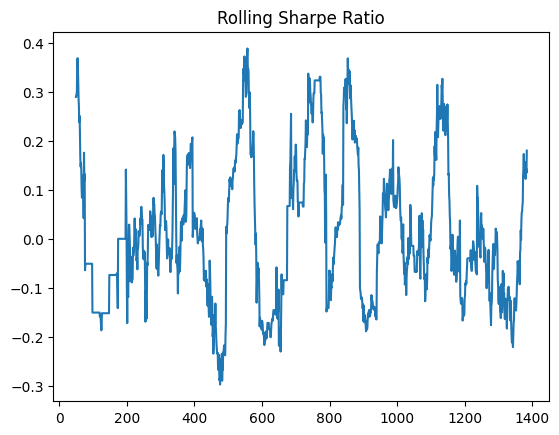

In [39]:
rolling_sharpe(wf_history)

In [40]:
def plot_drawdown(history):
    values = history['value']
    peak = values.cummax()
    drawdown = (values - peak) / peak

    plt.figure()
    plt.plot(drawdown)
    plt.title("Drawdown Curve")
    plt.show()

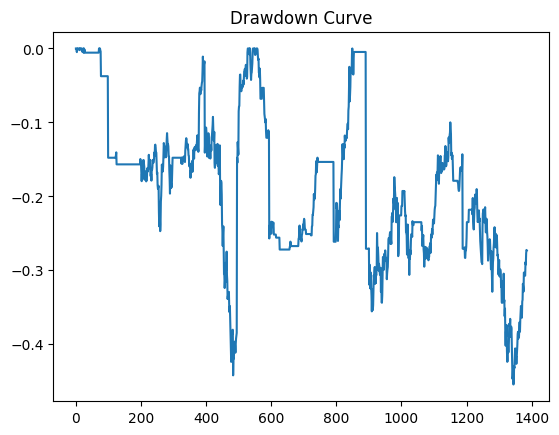

In [41]:
plot_drawdown(wf_history)

In [42]:
def buy_and_hold(df, initial_cash=10000):

    prices = df['Close'].values

    shares = initial_cash / prices[0]
    values = shares * prices

    history = pd.DataFrame({
        "step": range(len(values)),
        "price": prices,
        "value": values,
        "action": 0  # no actions
    })

    return history

In [43]:
def compare_with_benchmark(df, strategy_history):

    benchmark_history = buy_and_hold(df)

    plt.figure()
    plt.plot(strategy_history['value'].values, label="Strategy")
    plt.plot(benchmark_history['value'].values, label="Buy & Hold")

    plt.title("Strategy vs Buy & Hold")
    plt.legend()
    plt.show()

    return benchmark_history

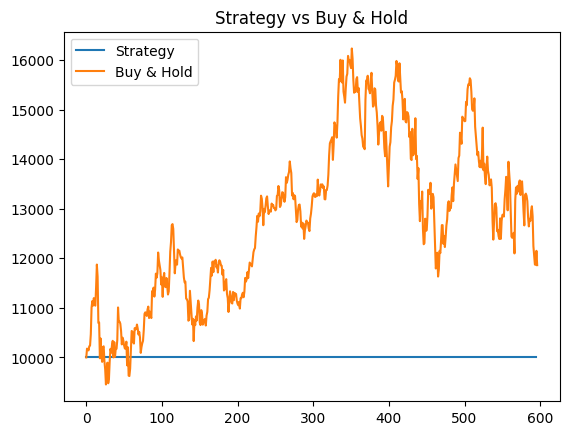

In [44]:
benchmark_history = compare_with_benchmark(test_df, history)

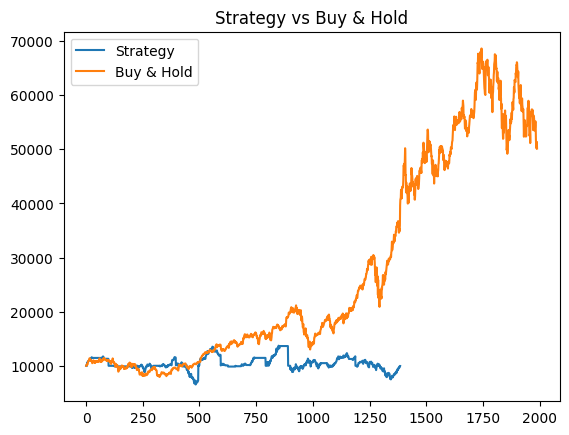

In [45]:
benchmark_wf = compare_with_benchmark(df, wf_history)

In [46]:
def performance_table(strategy_history, benchmark_history):

    def compute(values):
        returns = np.diff(np.log(values + 1e-8))
        sharpe = returns.mean() / (returns.std() + 1e-8)
        total_return = values[-1] / values[0] - 1
        return sharpe, total_return

    s_sharpe, s_ret = compute(strategy_history['value'].values)
    b_sharpe, b_ret = compute(benchmark_history['value'].values)

    table = pd.DataFrame({
        "Metric": ["Sharpe", "Total Return"],
        "Strategy": [s_sharpe, s_ret],
        "Buy_Hold": [b_sharpe, b_ret]
    })

    print(table)

In [47]:
performance_table(history, benchmark_history)

         Metric  Strategy  Buy_Hold
0        Sharpe       0.0  0.014068
1  Total Return       0.0  0.186162


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [48]:
from scipy import stats

def t_test_significance(strategy_history, benchmark_history):

    s_returns = np.diff(np.log(strategy_history['value'].values + 1e-8))
    b_returns = np.diff(np.log(benchmark_history['value'].values + 1e-8))

    t_stat, p_value = stats.ttest_ind(s_returns, b_returns, equal_var=False)

    print("T-Statistic:", t_stat)
    print("P-Value:", p_value)

    if p_value < 0.05:
        print("Statistically significant difference")
    else:
        print("Not statistically significant")

In [49]:
t_test_significance(history, benchmark_history)

T-Statistic: -0.3431524759488717
P-Value: 0.7316049615684046
Not statistically significant


In [50]:
def bootstrap_test(strategy_history, benchmark_history, n_bootstrap=1000):

    s_returns = np.diff(np.log(strategy_history['value'].values + 1e-8))
    b_returns = np.diff(np.log(benchmark_history['value'].values + 1e-8))

    diff_means = []

    for _ in range(n_bootstrap):
        s_sample = np.random.choice(s_returns, size=len(s_returns), replace=True)
        b_sample = np.random.choice(b_returns, size=len(b_returns), replace=True)

        diff_means.append(s_sample.mean() - b_sample.mean())

    diff_means = np.array(diff_means)

    p_value = np.mean(diff_means <= 0)

    print("Bootstrap P-Value:", p_value)

    plt.figure()
    plt.hist(diff_means, bins=50)
    plt.title("Bootstrap Distribution (Strategy - Benchmark)")
    plt.show()

Bootstrap P-Value: 0.619


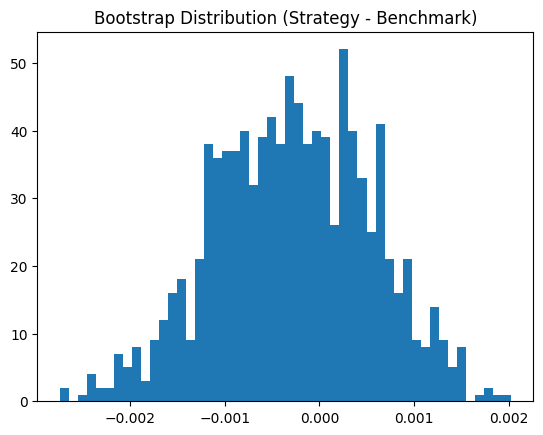

In [51]:
bootstrap_test(history, benchmark_history)